In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
# from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
# from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
# from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [2]:
import importlib
import parse_levels
importlib.reload(parse_levels)
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info


In [3]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
# def deduplicate_metrics(search_results):
#     records_length_so_far = {}
#     new_search_results = {}
#     for key, value in search_results.items():
#         if value['record'] not in records_length_so_far:
#             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#             new_search_results[key] = value
#         else:
#             if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
#                 new_search_results.pop(records_length_so_far[value['record']][1])

#                 records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#                 new_search_results[key] = value
#     return new_search_results



In [4]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#     ]
# )
# with open('/checkpoint/maui/zhaobc/scientist/code_analysis_with_all_versions_knowledge_o3_mini.json', 'r') as f:
#     o3_results = json.load(f)


In [5]:
# with open('may8.cache', 'w') as f:
#     json.dump(ori_results, f)

In [3]:
with open('/home/zhaobc/scientist/plot/may15.cache', 'r') as f:
    ori_results = json.load(f)

In [4]:
# z_folder_info = filter_folder_info(ori_results, [('levels', 'z')])
unique_levels = set()
for key, value in ori_results.items():
    unique_levels.add(value['levels'][0])
unique_levels

{1, 12, 125, 129, 19, 2, 5, 'z'}

In [8]:
# 1 is psuedo-code
# 2 is text description
# 5 is paper like 
# 9 is adhoc knowledge, we can ignore it for now
# 'z' is zero knowledge

In [5]:
folder_info = ori_results
# o3_results

In [6]:
len(folder_info)

3719

In [7]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in ['z', 1, 2, 5, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat z deepseek-r1 29
flat z o3-mini 60
flat 1 deepseek-r1 31
flat 1 o3-mini 99
flat 2 deepseek-r1 29
flat 2 o3-mini 60
flat 5 deepseek-r1 60
flat 5 o3-mini 60
flat 12 deepseek-r1 71
flat 12 o3-mini 64
flat 125 deepseek-r1 75
flat 125 o3-mini 55
tree z deepseek-r1 29
tree z o3-mini 60
tree 1 deepseek-r1 27
tree 1 o3-mini 106
tree 2 deepseek-r1 29
tree 2 o3-mini 60
tree 5 deepseek-r1 60
tree 5 o3-mini 60
tree 12 deepseek-r1 58
tree 12 o3-mini 51
tree 125 deepseek-r1 75
tree 125 o3-mini 74
forest z deepseek-r1 29
forest z o3-mini 60
forest 1 deepseek-r1 27
forest 1 o3-mini 106
forest 2 deepseek-r1 29
forest 2 o3-mini 60
forest 5 deepseek-r1 60
forest 5 o3-mini 60
forest 12 deepseek-r1 55
forest 12 o3-mini 64
forest 125 deepseek-r1 90
forest 125 o3-mini 70
ori_aide z deepseek-r1 29
ori_aide z o3-mini 60
ori_aide 1 deepseek-r1 24
ori_aide 1 o3-mini 106
ori_aide 2 deepseek-r1 29
ori_aide 2 o3-mini 60
ori_aide 5 deepseek-r1 57
ori_aide 5 o3-mini 57
ori_aide 12 deepseek-r1 55
ori_aide 12 o3-m

In [ ]:
# from tqdm import tqdm

# figure_data = {}
# for search_algo in search_algo_params.keys():
#     for level in ['z', 1, 2, 5, 12, 125]:
#         # for model in ['o3-mini']:
#         for model in ['deepseek-r1', 'o3-mini']:
#             # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
#             try:
#                 plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
#                 figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
#             except FileNotFoundError as e:
#                 print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")


In [21]:
# let's run for o3-mini only
figure_data_o3 = {}
for search_algo in search_algo_params.keys():
    for level in ['z', 1, 2, 5, 12, 125]:
        for model in ['o3-mini']:
            try:
                plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
                figure_data_o3[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
            except (FileNotFoundError, ValueError) as e:
                print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")
len(plot_info)
plot_info.keys()

dict_keys(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide'])

In [22]:
print(len(figure_data_o3))
figure_data_o3.keys()

30


dict_keys(['flat_z_o3-mini', 'flat_1_o3-mini', 'flat_2_o3-mini', 'flat_5_o3-mini', 'flat_12_o3-mini', 'flat_125_o3-mini', 'tree_z_o3-mini', 'tree_1_o3-mini', 'tree_2_o3-mini', 'tree_5_o3-mini', 'tree_12_o3-mini', 'tree_125_o3-mini', 'forest_z_o3-mini', 'forest_1_o3-mini', 'forest_2_o3-mini', 'forest_5_o3-mini', 'forest_12_o3-mini', 'forest_125_o3-mini', 'ori_aide_z_o3-mini', 'ori_aide_1_o3-mini', 'ori_aide_2_o3-mini', 'ori_aide_5_o3-mini', 'ori_aide_12_o3-mini', 'ori_aide_125_o3-mini', 'multi_aide_z_o3-mini', 'multi_aide_1_o3-mini', 'multi_aide_2_o3-mini', 'multi_aide_5_o3-mini', 'multi_aide_12_o3-mini', 'multi_aide_125_o3-mini'])

In [23]:
print(len(plot_info))
plot_info.keys()

5


dict_keys(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide'])

In [13]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}


In [24]:
plot_info

{'flat': {'z': {'deepseek-r1': {'record_8_20250504_161022_2201299-2200954-7': {'record': 8,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
     'n_hypotheses': 3,
     'debug_prob': None,
     'n_iterations': 1,
     'metrics':     step  val_loss  train_time
     0      0    3.2789    662205.0
     1      1    3.2768    676499.0
     2      2    3.2752    667604.0
     3      3    3.2741    672759.0
     4      4    3.2746    674163.0
     5      5    3.2746    675155.0
     6      6    3.2775    670727.0
     7      7    3.2749    672079.0
     8      8       NaN         NaN
     9      9       NaN         NaN
     10    10       NaN         NaN},
    'record_3_20250504_161022_2201294-2200954-2': {'record': 3,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
  

In [25]:
figure_data_o3


{'flat_z_o3-mini': defaultdict(list,
             {20: [('record_20_20250504_181028_2201675-2201675-1', 188680.0),
               ('record_20_20250511_135642_2256956-2256956-1', nan),
               ('record_20_20250511_135642_2256954-2256954-1', nan)],
              7: [('record_7_20250504_161020_2201193-2200949-6', 773072.0),
               ('record_7_20250511_135626_2256760-2256731-6', nan),
               ('record_7_20250511_135626_2256751-2256730-6', nan)],
              13: [('record_13_20250504_141038_2200340-2200325-2', 289805.0),
               ('record_13_20250511_135634_2257004-2256840-2', nan),
               ('record_13_20250511_135635_2257011-2256841-2', nan)],
              1: [('record_1_20250504_161020_2201186-2200949-0', 2189403.0),
               ('record_1_20250511_135626_2256754-2256731-0', nan),
               ('record_1_20250511_135626_2256745-2256730-0', nan)],
              3: [('record_3_20250504_161020_2201188-2200949-2', 1386147.0),
               ('record_3

In [14]:
len(figure_data)

60

In [26]:
figure_data_percent = {}
for key in figure_data_o3.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data_o3[key], human_train_time_dict, keep_name=True)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    try:
        del figure_data_percent[key]['6']
    except:
        pass

flat_z_o3-mini
flat_1_o3-mini
flat_2_o3-mini
flat_5_o3-mini
flat_12_o3-mini
flat_125_o3-mini
tree_z_o3-mini
tree_1_o3-mini
tree_2_o3-mini
tree_5_o3-mini
tree_12_o3-mini
tree_125_o3-mini
forest_z_o3-mini
forest_1_o3-mini
forest_2_o3-mini
forest_5_o3-mini
forest_12_o3-mini
forest_125_o3-mini
ori_aide_z_o3-mini
ori_aide_1_o3-mini
ori_aide_2_o3-mini
ori_aide_5_o3-mini
ori_aide_12_o3-mini
ori_aide_125_o3-mini
multi_aide_z_o3-mini
multi_aide_1_o3-mini
multi_aide_2_o3-mini
multi_aide_5_o3-mini
multi_aide_12_o3-mini
multi_aide_125_o3-mini


In [27]:
figure_data_percent

{'flat_z_o3-mini': {'7': array([0., 0., 0.]),
  '13': array([0., 0., 0.]),
  '1': array([1.02706013, 0.        , 0.        ]),
  '3': array([0., 0., 0.]),
  '11': array([0., 0., 0.]),
  '19': array([0., 0., 0.]),
  '14': array([0., 0., 0.]),
  '16': array([0., 0., 0.]),
  '5': array([0., 0., 0.]),
  '17': array([0., 0., 0.]),
  '8': array([0., 0., 0.]),
  '10': array([0., 0., 0.]),
  '4': array([0.05027654, 0.        , 0.        ]),
  '18': array([0.26794644, 0.        , 0.        ]),
  '15': array([0.16910033, 0.        , 0.        ]),
  '9': array([0.14428667, 0.        , 0.        ]),
  '2': array([0.66975366, 0.        , 0.        ]),
  '12': array([0.18135122, 0.        , 0.        ])},
 'flat_1_o3-mini': {'15': array([0.38577485, 0.        , 0.        , 0.        , 0.        ]),
  '8': array([0., 0., 0., 0., 0.]),
  '17': array([0.38856339, 0.        , 0.        , 0.        , 0.        ]),
  '5': array([0., 0., 0., 0., 0.]),
  '11': array([0.        , 0.        , 0.06942291, 0.  

In [28]:
figure_data_percent.keys()


dict_keys(['flat_z_o3-mini', 'flat_1_o3-mini', 'flat_2_o3-mini', 'flat_5_o3-mini', 'flat_12_o3-mini', 'flat_125_o3-mini', 'tree_z_o3-mini', 'tree_1_o3-mini', 'tree_2_o3-mini', 'tree_5_o3-mini', 'tree_12_o3-mini', 'tree_125_o3-mini', 'forest_z_o3-mini', 'forest_1_o3-mini', 'forest_2_o3-mini', 'forest_5_o3-mini', 'forest_12_o3-mini', 'forest_125_o3-mini', 'ori_aide_z_o3-mini', 'ori_aide_1_o3-mini', 'ori_aide_2_o3-mini', 'ori_aide_5_o3-mini', 'ori_aide_12_o3-mini', 'ori_aide_125_o3-mini', 'multi_aide_z_o3-mini', 'multi_aide_1_o3-mini', 'multi_aide_2_o3-mini', 'multi_aide_5_o3-mini', 'multi_aide_12_o3-mini', 'multi_aide_125_o3-mini'])

In [29]:
# Get top 3 values for each experiment, padding if needed
def get_top_3_values(arr, config=None, exp_name=None):
    if len(arr) == 0:
        return np.array([0, 0, 0])
    # Filter out values > 3 or < 0
    valid_arr = []
    for x in arr:
        if not (0 <= x <= 3):
            print(f"Warning: Value {x} from {config} {exp_name} outside valid range [0,3], replacing with 0")
            valid_arr.append(0)
        else:
            valid_arr.append(x)
    sorted_arr = np.sort(valid_arr)[::-1] # Sort descending
    if len(arr) >= 3:
        return sorted_arr[:3]
    else:
        # Pad with repeats of max value to get 3 numbers
        padding = 3 - len(arr)
        if not ('r1' in config):
            # Only log warning once per config
            if exp_name == list(figure_data_percent[config].keys())[0]:
                print(f"Warning: Config {config} has experiments with fewer than 3 values, padding with {padding} repeated values")
        return np.concatenate([sorted_arr, np.repeat(sorted_arr[-1], padding)])

# Process each config
results_by_config = {}
for config, experiments in figure_data_percent.items():
    print(f"Processing config: {config}")
    print(f"Experiments: {list(experiments.keys())}")
    # Get top 3 values for each experiment
    top3_by_experiment = {}
    if len(experiments) == 0:
        print(f'Warning: {config} has no experiments')
    for exp_name, values in experiments.items():
        print(f"Experiment Name: {exp_name}, Values: {values}")
        top3 = get_top_3_values(values, config, exp_name)
        top3_by_experiment[exp_name] = top3
    
    # Average across experiments for each of the 3 positions
    all_exp_values = np.array(list(top3_by_experiment.values()))
    mean_values = np.mean(all_exp_values, axis=0) # Shape (3,)
    
    # Calculate standard error of the mean (SEM) instead of std
    n = len(all_exp_values) if len(all_exp_values) > 0 else 1
    sem_value = np.std(mean_values) / np.sqrt(n)
    print("All experiment values (top 3 for each experiment):")
    print(all_exp_values)
    results_by_config[config] = {
        'means': np.mean(mean_values) if len(all_exp_values) > 0 else 0,
        'std': sem_value if len(all_exp_values) > 0 else 0,  # Using 'std' key for compatibility but storing SEM
        'all_exp_values': all_exp_values,
    }



Processing config: flat_z_o3-mini
Experiments: ['7', '13', '1', '3', '11', '19', '14', '16', '5', '17', '8', '10', '4', '18', '15', '9', '2', '12']
Experiment Name: 7, Values: [0. 0. 0.]
Experiment Name: 13, Values: [0. 0. 0.]
Experiment Name: 1, Values: [1.02706013 0.         0.        ]
Experiment Name: 3, Values: [0. 0. 0.]
Experiment Name: 11, Values: [0. 0. 0.]
Experiment Name: 19, Values: [0. 0. 0.]
Experiment Name: 14, Values: [0. 0. 0.]
Experiment Name: 16, Values: [0. 0. 0.]
Experiment Name: 5, Values: [0. 0. 0.]
Experiment Name: 17, Values: [0. 0. 0.]
Experiment Name: 8, Values: [0. 0. 0.]
Experiment Name: 10, Values: [0. 0. 0.]
Experiment Name: 4, Values: [0.05027654 0.         0.        ]
Experiment Name: 18, Values: [0.26794644 0.         0.        ]
Experiment Name: 15, Values: [0.16910033 0.         0.        ]
Experiment Name: 9, Values: [0.14428667 0.         0.        ]
Experiment Name: 2, Values: [0.66975366 0.         0.        ]
Experiment Name: 12, Values: [0.1813

In [ ]:
results_by_config['flat_125_o3-mini']

{'means': 0.2364127923638016,
 'std': 0.044738941178733595,
 'all_exp_values': array([[0.28802437, 0.10885868, 0.        ],
        [1.04967179, 0.79376058, 0.        ],
        [0.74759847, 0.        , 0.        ],
        [1.00770493, 0.10829707, 0.        ],
        [0.98258844, 0.95944759, 0.        ],
        [0.11151036, 0.        , 0.        ],
        [0.25576706, 0.16776899, 0.        ],
        [0.26966557, 0.20654734, 0.        ],
        [0.25506073, 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [1.04188497, 0.98706278, 0.        ],
        [0.        , 0.        , 0.        ],
        [0.07543989, 0.        , 0.        ],
        [0.26390469, 0.25274934, 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.52657499, 0.        , 0.        ],
        [1.48972904, 0.81667313, 0.        ]])}

In [41]:
results_by_config['flat_125_o3-mini']['all_exp_values'].shape

(18, 3)

In [ ]:
results_by_config_all_searches = {}

for hint_regime in ['z', '1', '2', '5', '12', '125']:
    key_suffix = f"{hint_regime}_o3-mini"
    combined_exp_values = []

    for search_method in ['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']:
        key = f"{search_method}_{key_suffix}"
        if key in results_by_config:
            combined_exp_values.append(results_by_config[key]['all_exp_values'])

    # Combine all experiments across searches
    combined_exp_values = np.vstack(combined_exp_values)
    results_by_config_all_searches[f"{key_suffix}_all_searches"] = {
        'all_exp_values': combined_exp_values
    }

In [38]:
results_by_config_all_searches.keys()

dict_keys(['z_o3-mini_all_searches', '1_o3-mini_all_searches', '2_o3-mini_all_searches', '5_o3-mini_all_searches', '12_o3-mini_all_searches', '125_o3-mini_all_searches'])

In [40]:
results_by_config_all_searches['z_o3-mini_all_searches']['all_exp_values'].shape

(90, 3)

In [31]:
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

In [47]:
results_by_config_all_searches.keys()


dict_keys(['z_o3-mini_all_searches', '1_o3-mini_all_searches', '2_o3-mini_all_searches', '5_o3-mini_all_searches', '12_o3-mini_all_searches', '125_o3-mini_all_searches'])

In [48]:
len(results_by_config_all_searches)

6

In [50]:
results_by_config_all_searches['z_o3-mini_all_searches']

{'all_exp_values': array([[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [1.02706013, 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.05027654, 0.        , 0.        ],
        [0.26794644, 0.        , 0.        ],
        [0.16910033, 0.        , 0.        ],
        [0.14428667, 0.        , 0.        ],
        [0.66975366, 0.        , 0.        ],
        [0.18135122, 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.02356448, 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.     

In [ ]:
# algorithms = ['DQN (Nature)', 'DQN (Adam)', 'C51', 'REM', 'Rainbow',
#               'IQN', 'M-IQN', 'DreamerV2']
searches = ['z_o3-mini_all_searches', '1_o3-mini_all_searches', '2_o3-mini_all_searches', '5_o3-mini_all_searches', '12_o3-mini_all_searches', '125_o3-mini_all_searches']
# Load ALE scores as a dictionary mapping algorithms to their human normalize
# score matrices, each of which is of size `(num_runs x num_games)`.
# atari_200m_normalized_score_dict = ...
searches_fsr_all_exp_values_dict = {key: value['all_exp_values'] for key, value in results_by_config_all_searches.items()}
aggregate_func = lambda x: np.array([
  metrics.aggregate_median(x),
  metrics.aggregate_iqm(x),
  metrics.aggregate_mean(x),
  metrics.aggregate_optimality_gap(x)])

In [54]:
aggregate_scores_all_searches, aggregate_score_cis_all_searches = rly.get_interval_estimates(
  searches_fsr_all_exp_values_dict, aggregate_func, reps=50000)


INFO:absl:Calculating estimates for z_o3-mini_all_searches ...
INFO:absl:Calculating estimates for 1_o3-mini_all_searches ...
INFO:absl:Calculating estimates for 2_o3-mini_all_searches ...
INFO:absl:Calculating estimates for 5_o3-mini_all_searches ...
INFO:absl:Calculating estimates for 12_o3-mini_all_searches ...
INFO:absl:Calculating estimates for 125_o3-mini_all_searches ...


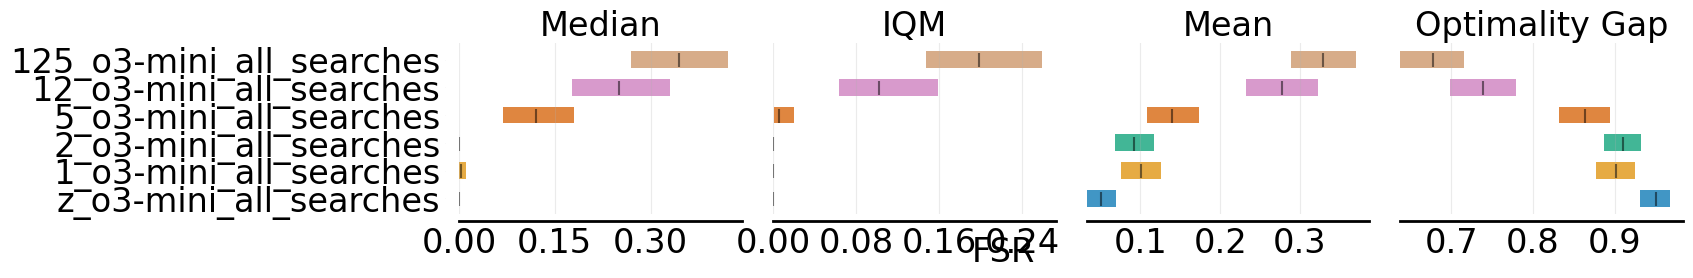

In [56]:
searches = ['z_o3-mini_all_searches', '1_o3-mini_all_searches', '2_o3-mini_all_searches', '5_o3-mini_all_searches', '12_o3-mini_all_searches', '125_o3-mini_all_searches']
fig, axes = plot_utils.plot_interval_estimates(
  aggregate_scores_all_searches, aggregate_score_cis_all_searches,
  metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
  algorithms=searches, xlabel='FSR')

Text(0.5, 0, 'FSR')

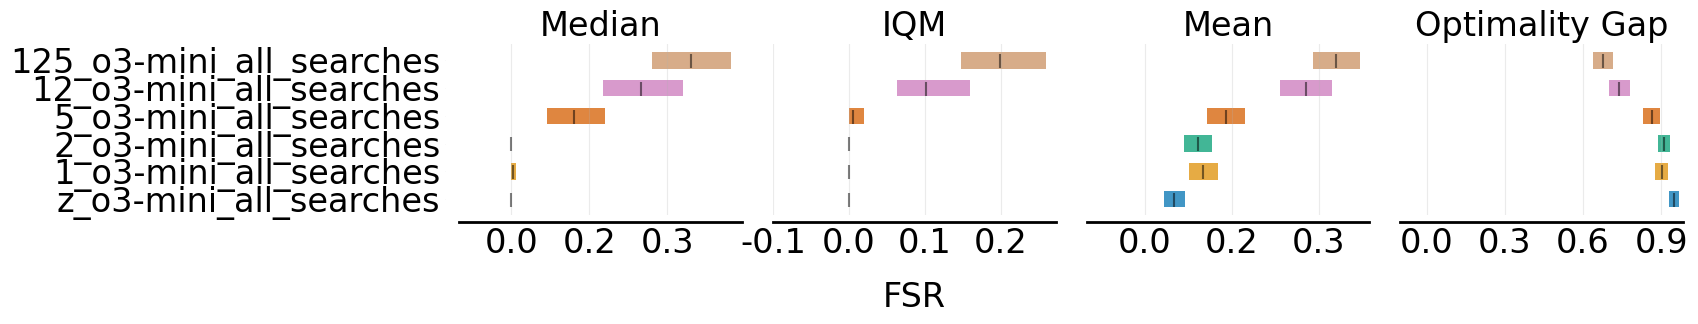

In [61]:
from matplotlib.ticker import FuncFormatter

# Define a formatter to reduce the number of decimal digits
formatter = FuncFormatter(lambda x, _: f'{x:.1f}')

fig, axes = plot_utils.plot_interval_estimates(
    aggregate_scores_all_searches, aggregate_score_cis_all_searches,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=searches, xlabel='',)

# Apply the formatter to all x-axes
for ax in axes:
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(left=-0.1)  # Set the x-axis to start from -0.

# Adjust the position and font size of the xlabel for the IQM plot to avoid overlap
axes[1].set_xlabel('FSR', labelpad=15, fontsize=24)  # Increase labelpad and fontsize

In [63]:
results_by_config_all_hints = {}
for search_method in ['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']:
    key_suffix = f"{search_method}_o3-mini"
    combined_exp_values = []

    for hint_regime in ['z', '1', '2', '5', '12', '125']:
        key = f"{search_method}_{hint_regime}_o3-mini"
        if key in results_by_config:
            combined_exp_values.append(results_by_config[key]['all_exp_values'])

    # Combine all experiments across hint regimes
    combined_exp_values = np.vstack(combined_exp_values)
    results_by_config_all_hints[f"{search_method}_o3-mini_all_hints"] = {
        'all_exp_values': combined_exp_values
    }

In [64]:
len(results_by_config_all_hints)

5

In [65]:
results_by_config_all_hints.keys()

dict_keys(['flat_o3-mini_all_hints', 'tree_o3-mini_all_hints', 'forest_o3-mini_all_hints', 'ori_aide_o3-mini_all_hints', 'multi_aide_o3-mini_all_hints'])

In [67]:
results_by_config_all_hints['flat_o3-mini_all_hints']['all_exp_values'].shape

(108, 3)

In [68]:
searches = ['flat_o3-mini_all_hints', 'tree_o3-mini_all_hints', 'forest_o3-mini_all_hints', 'ori_aide_o3-mini_all_hints', 'multi_aide_o3-mini_all_hints']
# Load ALE scores as a dictionary mapping algorithms to their human normalize
# score matrices, each of which is of size `(num_runs x num_games)`.
# atari_200m_normalized_score_dict = ...
searches_fsr_all_exp_values_dict = {key: value['all_exp_values'] for key, value in results_by_config_all_searches.items()}
aggregate_func = lambda x: np.array([
  metrics.aggregate_median(x),
  metrics.aggregate_iqm(x),
  metrics.aggregate_mean(x),
  metrics.aggregate_optimality_gap(x)])